In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [2]:
# Load and merge
df1 = pd.read_excel("AWS_CVE.xlsx", header=0)
df2 = pd.read_excel("Azure_CVE.xlsx", header=0)
df3 = pd.read_excel("GoogleCloud_CVE.xlsx", header=0)

df1['Provider'] = 'AWS'
df2['Provider'] = 'Azure'
df3['Provider'] = 'GoogleCloud'

merged = pd.concat([df1, df2, df3], ignore_index=True)
merged.dropna(how='all', inplace=True)
merged = merged.loc[:, merged.notna().any()]
merged = merged[merged['CVE-ID'].notna()].reset_index(drop=True)

merged.to_excel("merged_CVE.xlsx", index=False)

print(merged.shape)
print(merged.columns.tolist())
merged.head()

(720, 24)
['Date', 'CVE-ID', 'Published date', 'Last Update date', 'EPSS', 'CWE-ID', 'CWE Name', 'CVSS 4.0', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'CVSS 3.x', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'CVSS 2.0', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Description', 'Provider']


,Date,CVE-ID,Published date,Last Update date,EPSS,CWE-ID,CWE Name,CVSS 4.0,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,CVSS 2.0,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Description,Provider
0,2025-05-21,CVE-2025-4318,2025-05-05,2025-05-05 00:00:00,0.0006,CWE-95,Improper Neutralization of Directives in Dynam...,CVSS:4.0/AV:N/AC:L/AT:P/PR:N/UI:N/VC:H/VI:H/VA...,9.5,CRITICAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,The AWS Amplify Studio UI component property e...,AWS
1,2025-05-21,CVE-2025-3857,2025-04-21,2025-04-23 00:00:00,0.0005,"CWE-502, CWE-835","Deserialization of Untrusted Data(CWE-502), Lo...",CVSS:4.0/AV:N/AC:L/AT:N/PR:N/UI:N/VC:N/VI:N/VA...,8.7,HIGH,...,HIGH,3.6,3.9,NaN,NaN,NaN,NaN,NaN,When reading binary Ion data through Amazon.Io...,AWS
2,2025-05-21,CVE-2025-3047,2025-03-31,2025-04-01 00:00:00,0.0001,"CWE-22, CWE-497",Improper Limitation of a Pathname to a Restric...,CVSS:4.0/AV:N/AC:L/AT:N/PR:N/UI:A/VC:H/VI:N/VA...,6.9,MEDIUM,...,MEDIUM,3.6,2.8,NaN,NaN,NaN,NaN,NaN,When running the AWS Serverless Application Mo...,AWS
3,2025-05-21,CVE-2025-3048,2025-03-31,2025-04-01 00:00:00,0.0001,"CWE-22, CWE-497",Improper Limitation of a Pathname to a Restric...,CVSS:4.0/AV:N/AC:L/AT:N/PR:N/UI:A/VC:H/VI:N/VA...,6.9,MEDIUM,...,MEDIUM,3.6,2.8,NaN,NaN,NaN,NaN,NaN,After completing a build with AWS Serverless A...,AWS
4,2025-05-21,CVE-2025-2885,2025-03-27,2025-03-28 00:00:00,0.0010,CWE-1288,Improper Validation of Consistency within Input,CVSS:4.0/AV:N/AC:H/AT:N/PR:H/UI:P/VC:N/VI:H/VA...,5.7,MEDIUM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missing validation of the root metatdata versi...,AWS


In [3]:
merged.rename(columns={
    'Unnamed: 8': 'cvss4_score', 'Unnamed: 9': 'cvss4_severity',
    'Unnamed: 13': 'cvss3_score', 'Unnamed: 14': 'cvss3_severity',
    'Unnamed: 15': 'cvss3_impact', 'Unnamed: 16': 'cvss3_exploit',
    'Unnamed: 18': 'cvss2_score', 'Unnamed: 19': 'cvss2_severity',
}, inplace=True)

merged = merged[~merged['cvss3_severity'].isin(['Severity'])].reset_index(drop=True)

def pick_severity(row):
    for col in ['cvss3_severity', 'cvss4_severity', 'cvss2_severity']:
        v = str(row.get(col, '')).strip().upper()
        if v in {'CRITICAL', 'HIGH', 'MEDIUM', 'LOW'}:
            return v
    return None

merged['Severity'] = merged.apply(pick_severity, axis=1)
merged = merged.dropna(subset=['Severity']).reset_index(drop=True)
print(merged['Severity'].value_counts())

Severity
HIGH        343
MEDIUM      263
CRITICAL     93
LOW           6
Name: count, dtype: int64


In [4]:
for col in ['cvss3_score', 'cvss4_score', 'cvss2_score', 'cvss3_impact', 'cvss3_exploit', 'EPSS']:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')

merged['cvss_score']  = merged['cvss3_score'].fillna(merged['cvss4_score']).fillna(merged['cvss2_score'])
merged['provider_enc'] = LabelEncoder().fit_transform(merged['Provider'])
merged['cwe_enc']      = LabelEncoder().fit_transform(merged['CWE-ID'].str.extract(r'(CWE-\d+)').fillna('CWE-UNKNOWN')[0])

FEATURES = ['cvss_score', 'cvss3_impact', 'cvss3_exploit', 'EPSS', 'provider_enc', 'cwe_enc']

data = merged[FEATURES + ['Severity']].dropna().reset_index(drop=True)
X = data[FEATURES].values

le = LabelEncoder()
y = le.fit_transform(data['Severity'].values)
CLASSES = le.classes_

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", len(X_train), " Test:", len(X_test))
print("Classes:", CLASSES)

Train: 541  Test: 136
Classes: ['CRITICAL' 'HIGH' 'LOW' 'MEDIUM']


In [5]:
RANDOM_STATE = 42

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    "Decision Tree":        DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "SVM":                  SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE),
}

results = []
cms = {}
probs = {}

for name, model in models.items():
    start = time.time()
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)

    results.append([name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0)
    ])
    cm = confusion_matrix(y_test, y_pred)
    cms[name]   = cm / cm.sum(axis=1, keepdims=True)
    probs[name] = y_prob
    print(f"{name} finished in {time.time()-start:.1f}s")

df_perf = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"]) \
            .sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(df_perf.to_string(index=False))

Logistic Regression finished in 0.0s
Decision Tree finished in 0.0s
Random Forest finished in 0.3s
Gradient Boosting finished in 0.7s
SVM finished in 0.0s
              Model  Accuracy  Precision   Recall       F1
      Random Forest  0.992647   0.992757 0.992647 0.992638
  Gradient Boosting  0.992647   0.992757 0.992647 0.992638
      Decision Tree  0.985294   0.985727 0.985294 0.985262
                SVM  0.955882   0.956509 0.955882 0.956071
Logistic Regression  0.948529   0.958203 0.948529 0.951787


In [6]:
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score  = pipe.score(X_test, y_test)
    diff = train_score - test_score
    flag = " ⚠ possible overfit" if diff > 0.05 else ""
    print(f"{name:25s}  train={train_score:.4f}  test={test_score:.4f}  diff={diff:.4f}{flag}")

Logistic Regression        train=0.9723  test=0.9485  diff=0.0237
Decision Tree              train=1.0000  test=0.9853  diff=0.0147
Random Forest              train=1.0000  test=0.9926  diff=0.0074
Gradient Boosting          train=1.0000  test=0.9926  diff=0.0074
SVM                        train=0.9630  test=0.9559  diff=0.0071


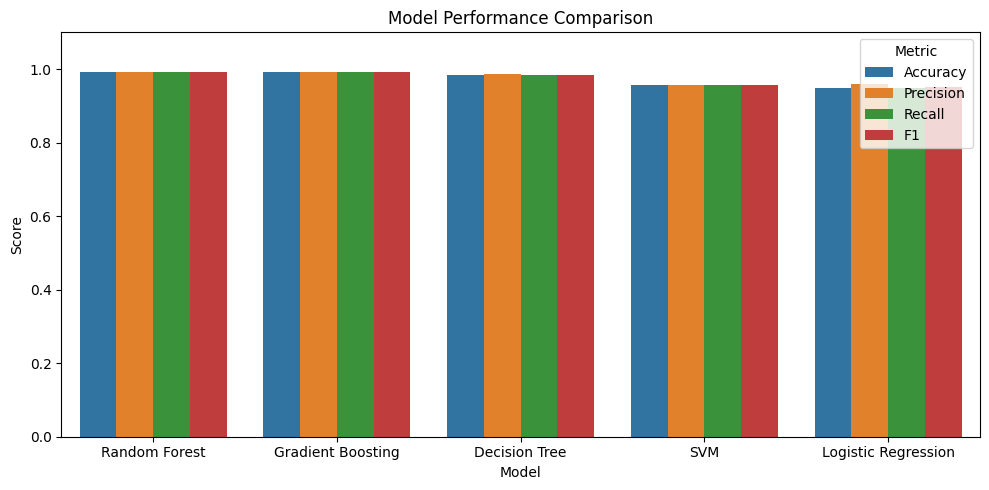

In [7]:
df_melt = df_perf.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 5))
sns.barplot(data=df_melt, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1.1)
plt.title('Model Performance Comparison')
plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

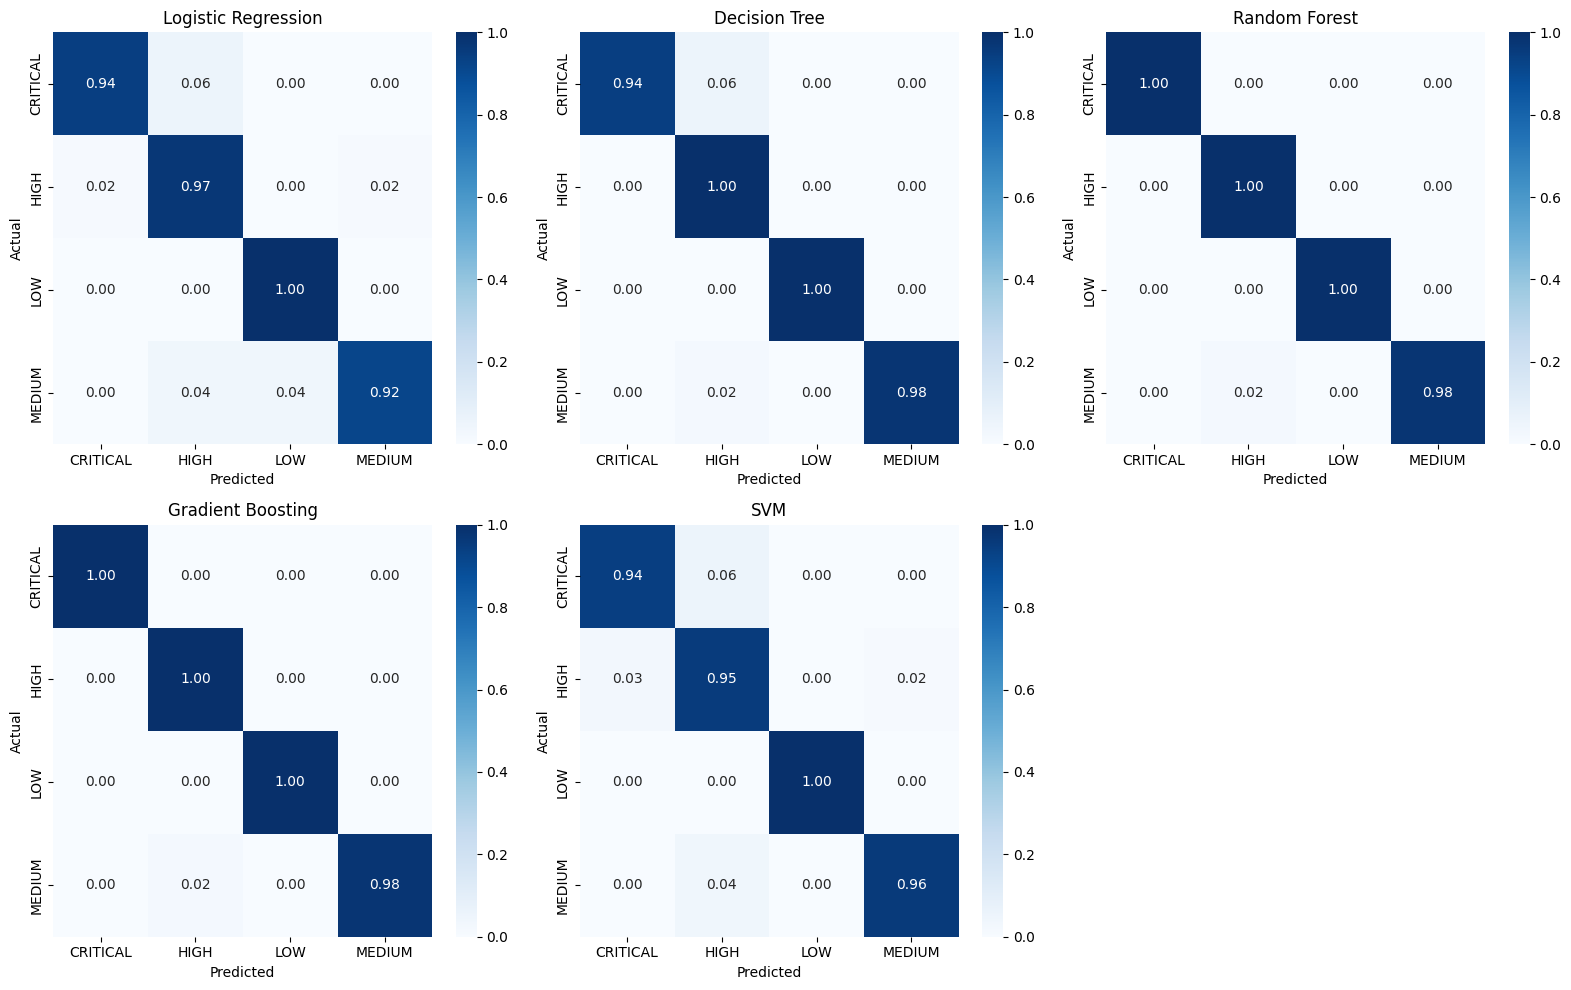

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, (name, cm) in enumerate(cms.items()):
    sns.heatmap(cm, annot=True, fmt='.2f', ax=axes[i], cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

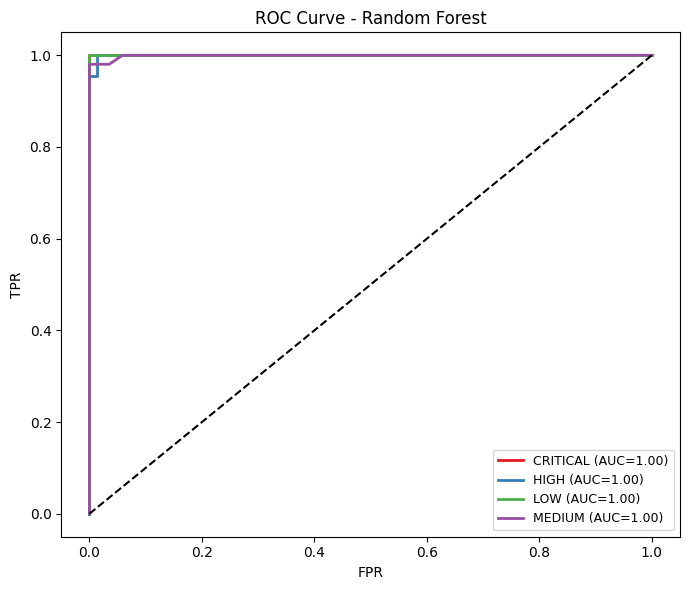

In [9]:
best_name = df_perf.iloc[0]['Model']
y_prob = probs[best_name]
y_bin = label_binarize(y_test, classes=list(range(len(CLASSES))))

fig, ax = plt.subplots(figsize=(7, 6))
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for j, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, j], y_prob[:, j])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.2f})')

ax.plot([0,1],[0,1],'k--')
ax.set_title(f'ROC Curve - {best_name}')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()